
# 2.1: Operations on vectors

In the previous section, we defined a vector $\vec{v}\in \mathbb{R}^n$ formally as an ordered array of real numbers. While this provides a useful way to organize data or represent coordinates, the true mathematical utility of vectors arises from how they interact with one another.

In this section, we introduce the two fundamental algebraic operations that allow us to manipulate these arrays: vector addition and scalar multiplication.

## Addition

### Algebraic definition

**Vector addition** is an operation between two vectors of the same dimension, where we 'add each entry by entry'. Here are some examples of how to add to vectors:
$$\begin{bmatrix} 1 \\ 2 \end{bmatrix} + \begin{bmatrix} 3 \\ -1 \end{bmatrix} = \begin{bmatrix} 4 \\ 1 \end{bmatrix}, \qquad \begin{bmatrix} 1 \\ 0 \\ -2 \end{bmatrix} + \begin{bmatrix} 2 \\ 5 \\ 3 \end{bmatrix} = \begin{bmatrix} 3 \\ 5 \\ 1 \end{bmatrix}.$$

Generally we can define addition as:

$$\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} + \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} = \begin{bmatrix} x_1 + y_1 \\ x_2 + y_2 \\ \vdots \\ x_n + y_n \end{bmatrix}.$$


### Geometric interpretation

A good way to think about vector addition (at least in dimensions 2 and 3) is to view the vectors as arrows and form a triangle. We obtain the sum $\vec u + \vec v$ by drawing the vector $\vec u$, drawing the vector $\vec v$ at the endpoint of $\vec u$, and connecting the two endpoints.

Here is an example of this viewpoint for:
$$ \vec u = \begin{bmatrix} 1 \\ 2 \end{bmatrix},\ 
\vec v =  \begin{bmatrix} 3 \\ -1 \end{bmatrix},\ 
\vec u + \vec v = \begin{bmatrix} 4 \\ 1 \end{bmatrix}. $$

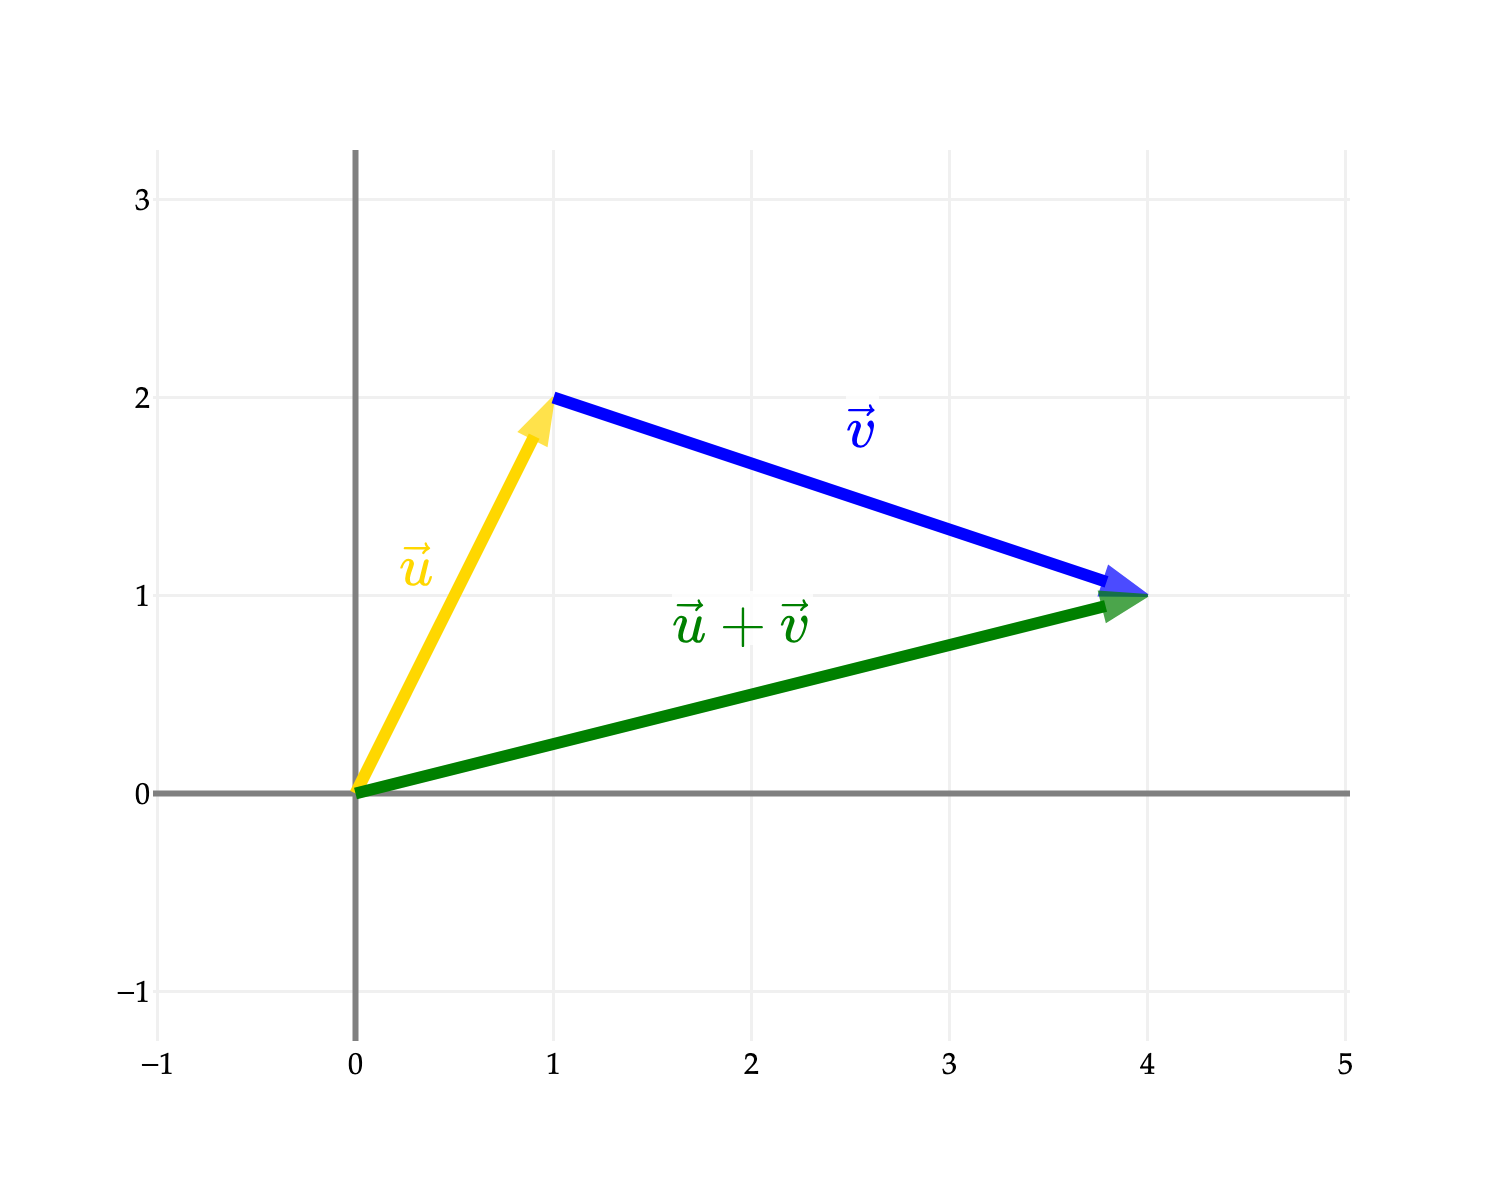

In [1]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# Define vectors in the format: (((start_x, start_y), (end_x, end_y)), color, label)
vectors = [
    (((0, 0), (1, 2)), 'gold', r'$\vec u$'),              # u starts at origin
    (((1, 2), (4, 1)), 'blue', r'$\vec v$'),                # v starts at tip of u
    (((0, 0), (4, 1)), 'green', r'$\vec u + \vec v$')       # u+v starts at origin, ends at tip of v
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.2, vdeltay=0.4)

fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-2, 7))
fig.update_yaxes(range=[-1, 3], tickvals=np.arange(-2, 5))

fig.show(scale=3)

This same interpretation of adding two vectors works for vectors in three dimensions as well. We form a triangle by connecting the two vectors in 3D space.

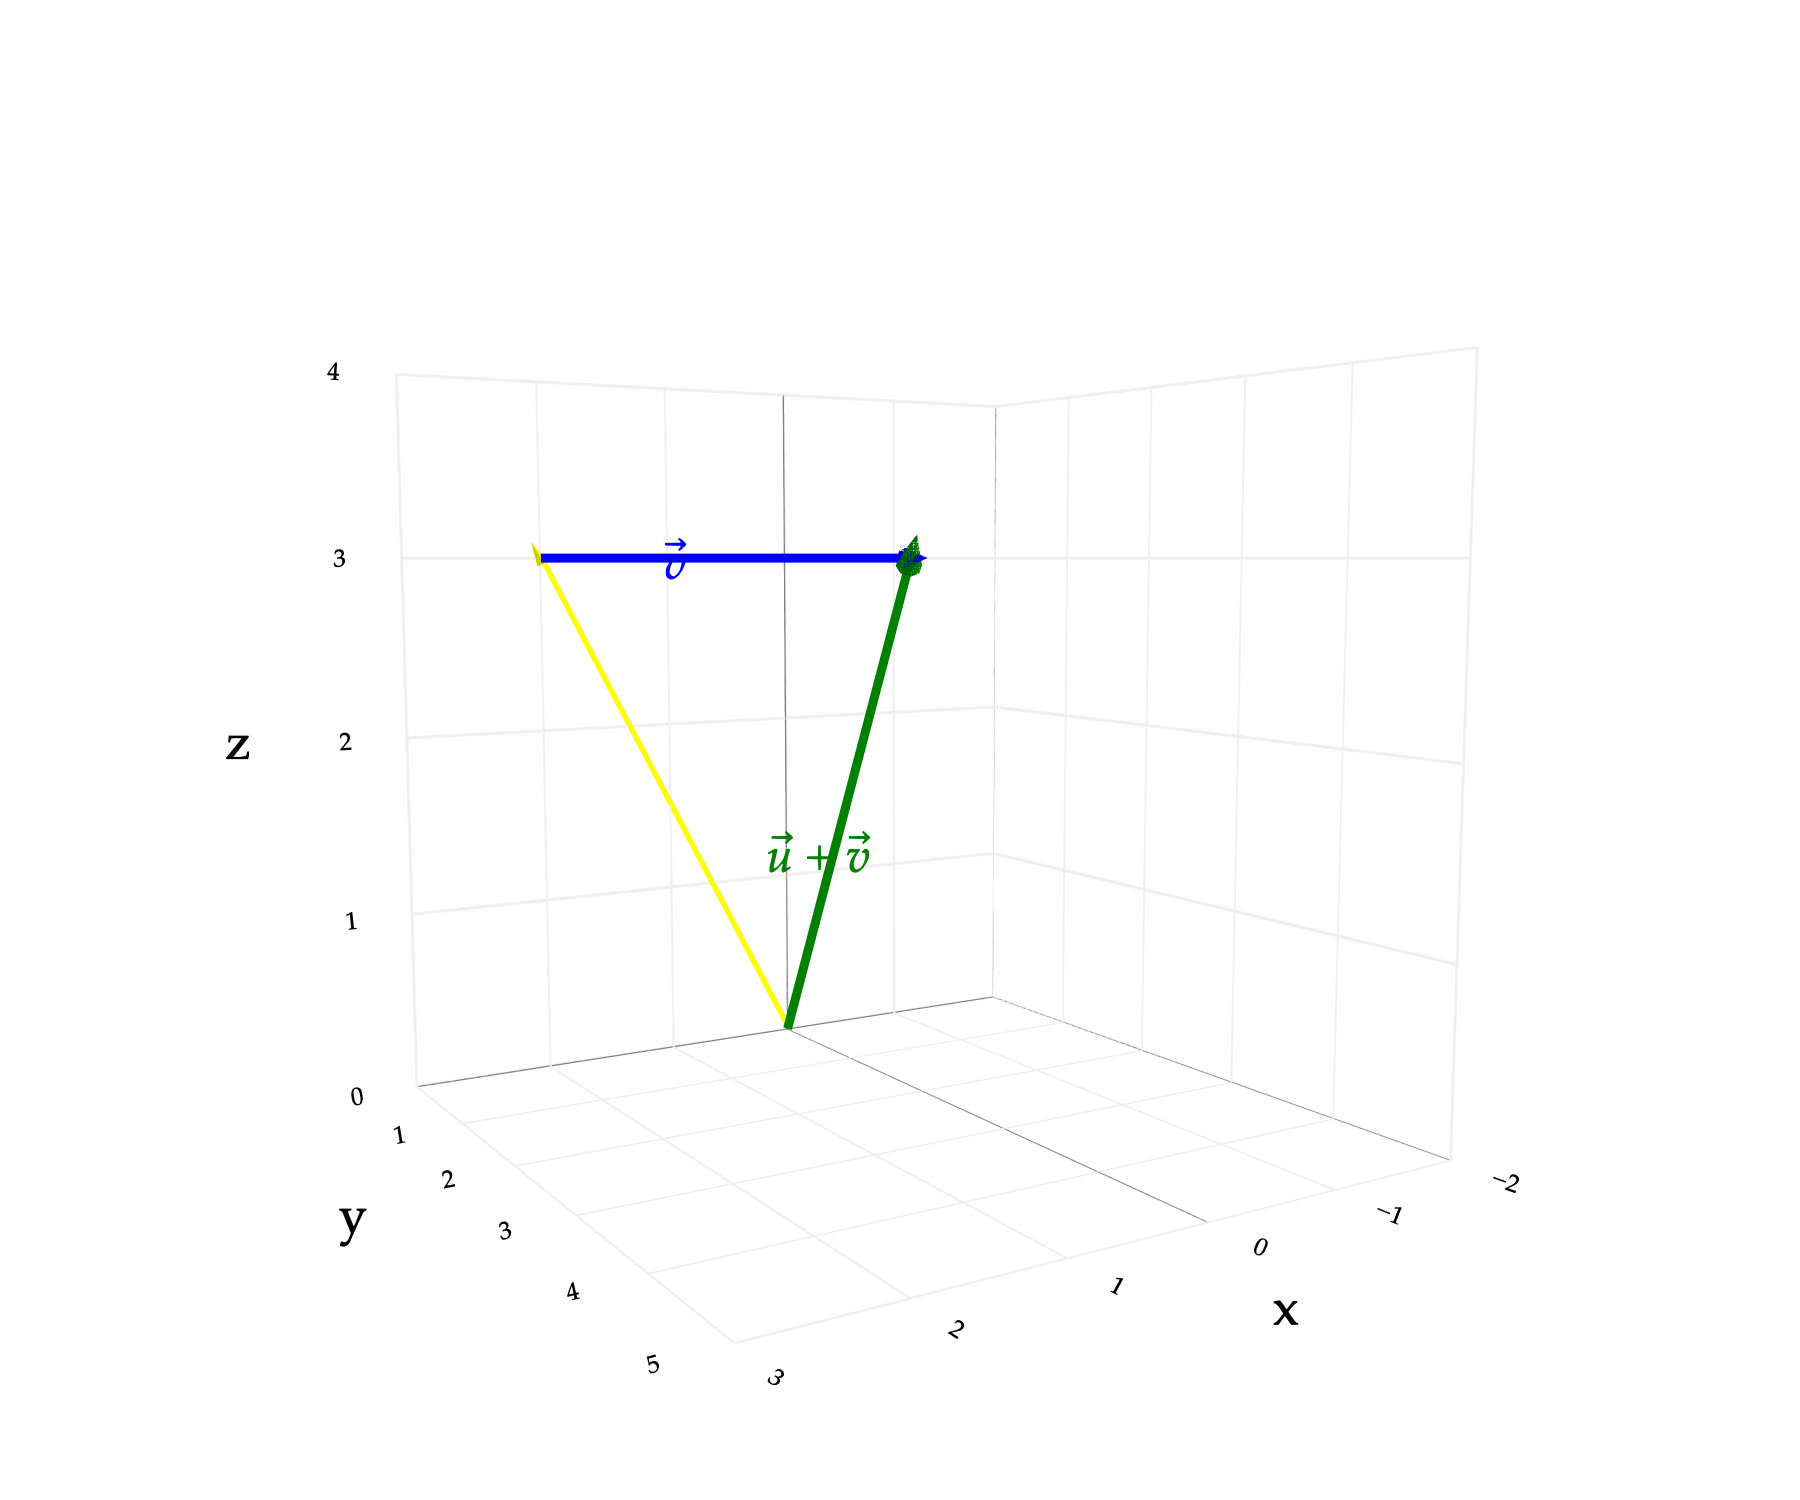

In [ ]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# Define 3D vectors: (((start_x, start_y, start_z), (end_x, end_y, end_z)), color, label)
# u = (2, 2, 1), v = (-1, 2, 2), u+v = (1, 4, 3)
vectors = [
    (((0, 0, 0), (2, 0, 3)), 'yellow', '<i>u</i>\u20D7'),
    (((2, 0, 3), (2, 5, 3)), 'blue', '<i>v</i>\u20D7'),
    (((0, 0, 0), (2, 5, 3)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7')
]

# Adjust offsets for the 3D labels
fig = plot_vectors_non_origin(vectors, vdeltax=0.2, vdeltay=0.2, vdeltaz=0.2)

# Frame the grid nicely around these specific coordinates
fig.update_layout(
    width=600, 
    height=500,
    scene=dict(
        xaxis=dict(range=[-2, 3], dtick=1),
        yaxis=dict(range=[0, 5], dtick=1),
        zaxis=dict(range=[0, 4], dtick=1),
        aspectratio=dict(x=1, y=1, z=1)
    )
)

fig.show(scale=3)

A nearly identical viewpoint -- but which will be more helpful when we deal with _subtracting_ two vectors -- is to put both vectors $\vec u$ and $\vec v$ be starting at the origin, and interpret $\vec u + \vec v$ as the diagonal of the parallelogram formed by the two vectors.

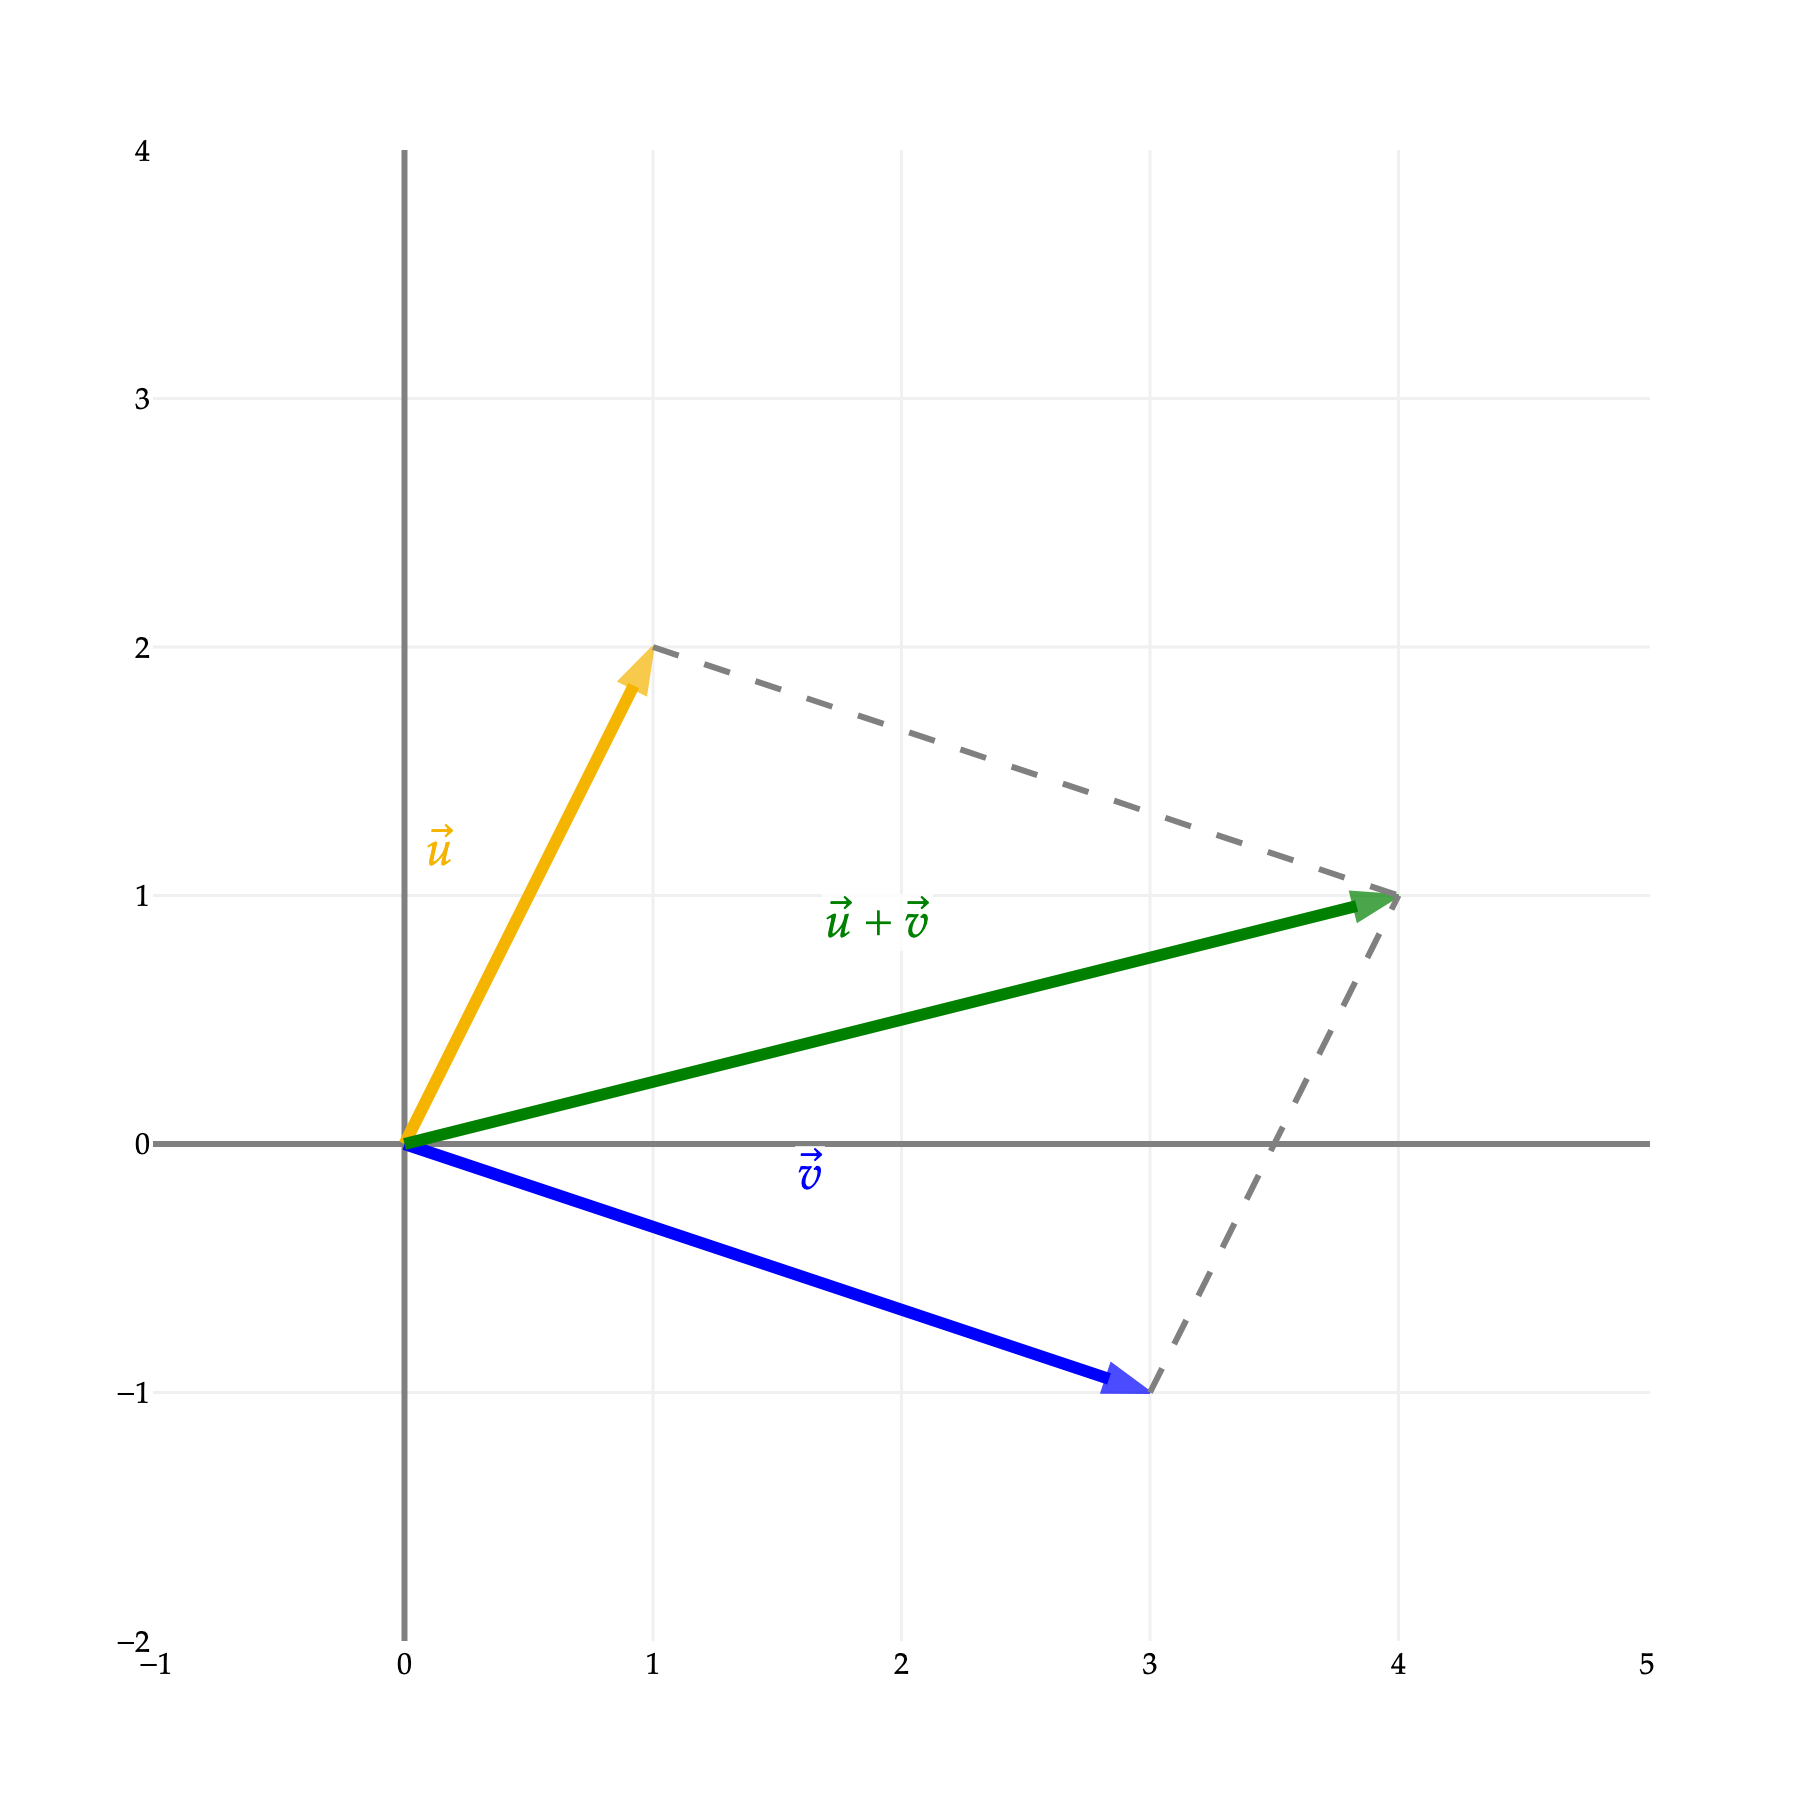

In [5]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the primary vectors and their resultant sum starting from the origin
vectors = [
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), 'blue', '<i>v</i>\u20D7'),
    (((0, 0), (4, 1)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)

# Add dashed lines to explicitly show the parallelogram
# 1. Edge parallel to v, starting at the tip of u (1, 2) and ending at the sum (4, 1)
fig.add_trace(go.Scatter(
    x=[1, 4], y=[2, 1], mode='lines', 
    line=dict(color='gray', width=2, dash='dash'), 
    showlegend=False, hoverinfo='skip'
))

# 2. Edge parallel to u, starting at the tip of v (3, -1) and ending at the sum (4, 1)
fig.add_trace(go.Scatter(
    x=[3, 4], y=[-1, 1], mode='lines', 
    line=dict(color='gray', width=2, dash='dash'), 
    showlegend=False, hoverinfo='skip'
))

# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid to comfortably frame the entire parallelogram
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

# Export statically
fig.show(scale=3)

### Associativity of addition

How about adding three vectors $\vec u$, $\vec v$ and $\vec w$? We can iterate the process above, first forming the vector $\vec u + \vec v$ as a triangle and then adding $\vec w$ to it. This will also show us that just like the usual addition for numbers, the order in which we add the three vectors does not matter. This is called the **associativity** of vector addition. Let's demonstrate this with another example. Take the vectors
$$ \vec u = \begin{bmatrix} 1 \\ 2 \end{bmatrix},\ 
\vec v =  \begin{bmatrix} 3 \\ -1 \end{bmatrix},\ 
\vec w = \begin{bmatrix} -1 \\ 2 \end{bmatrix}.$$

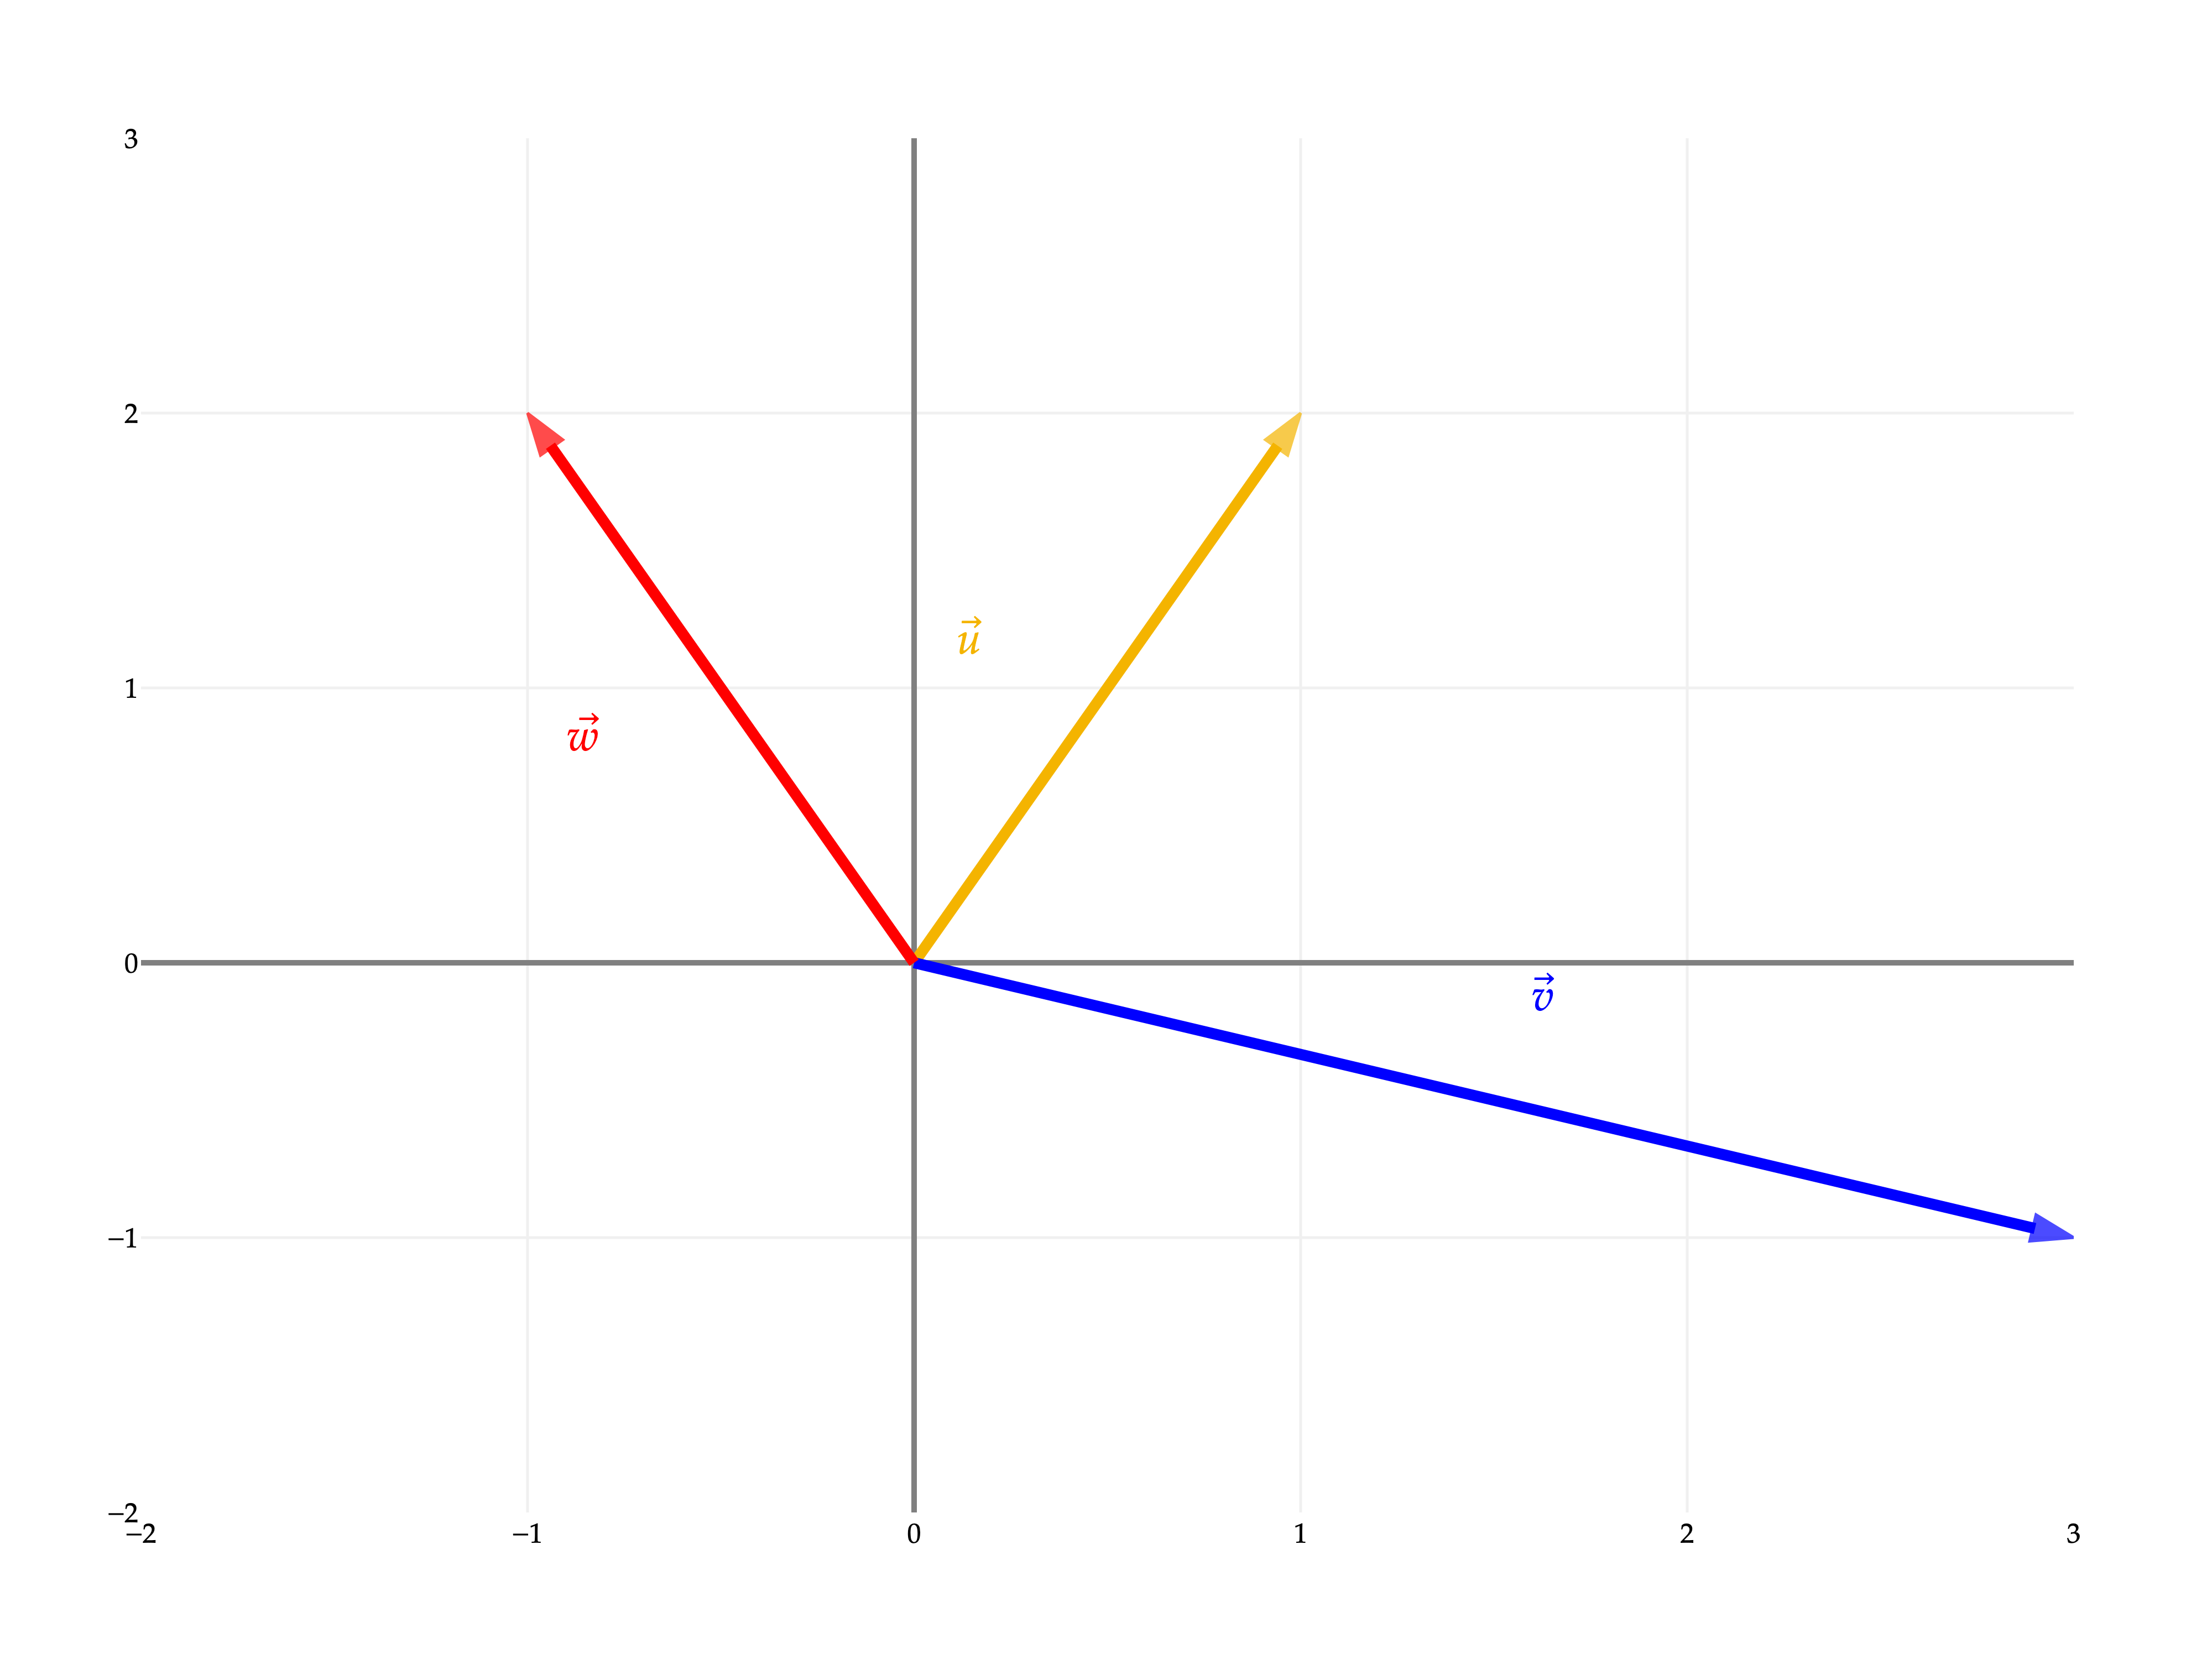

In [ ]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image (Kaleido safe)
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# 1. Vectors u, v, w all emitting from the origin
vectors_1 = [
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), 'blue', '<i>v</i>\u20D7'),
    (((0, 0), (-1, 2)), 'red', '<i>w</i>\u20D7')
]

fig1 = plot_vectors_non_origin(vectors_1, vdeltax=0.4, vdeltay=0.4)

fig1.update_xaxes(range=[-2, 3], tickvals=np.arange(-2,4))
fig1.update_yaxes(range=[-2, 3], tickvals=np.arange(-2,4))

fig1.show(scale=3)

Let us add the two vectors $\vec u$ and $\vec v$ first, and then add $\vec w$. From this we obtain
$$ (\vec u + \vec v) + \vec w = \begin{bmatrix}4\\1\end{bmatrix} + \begin{bmatrix}-1\\2\end{bmatrix} = \begin{bmatrix}3\\3\end{bmatrix}.$$

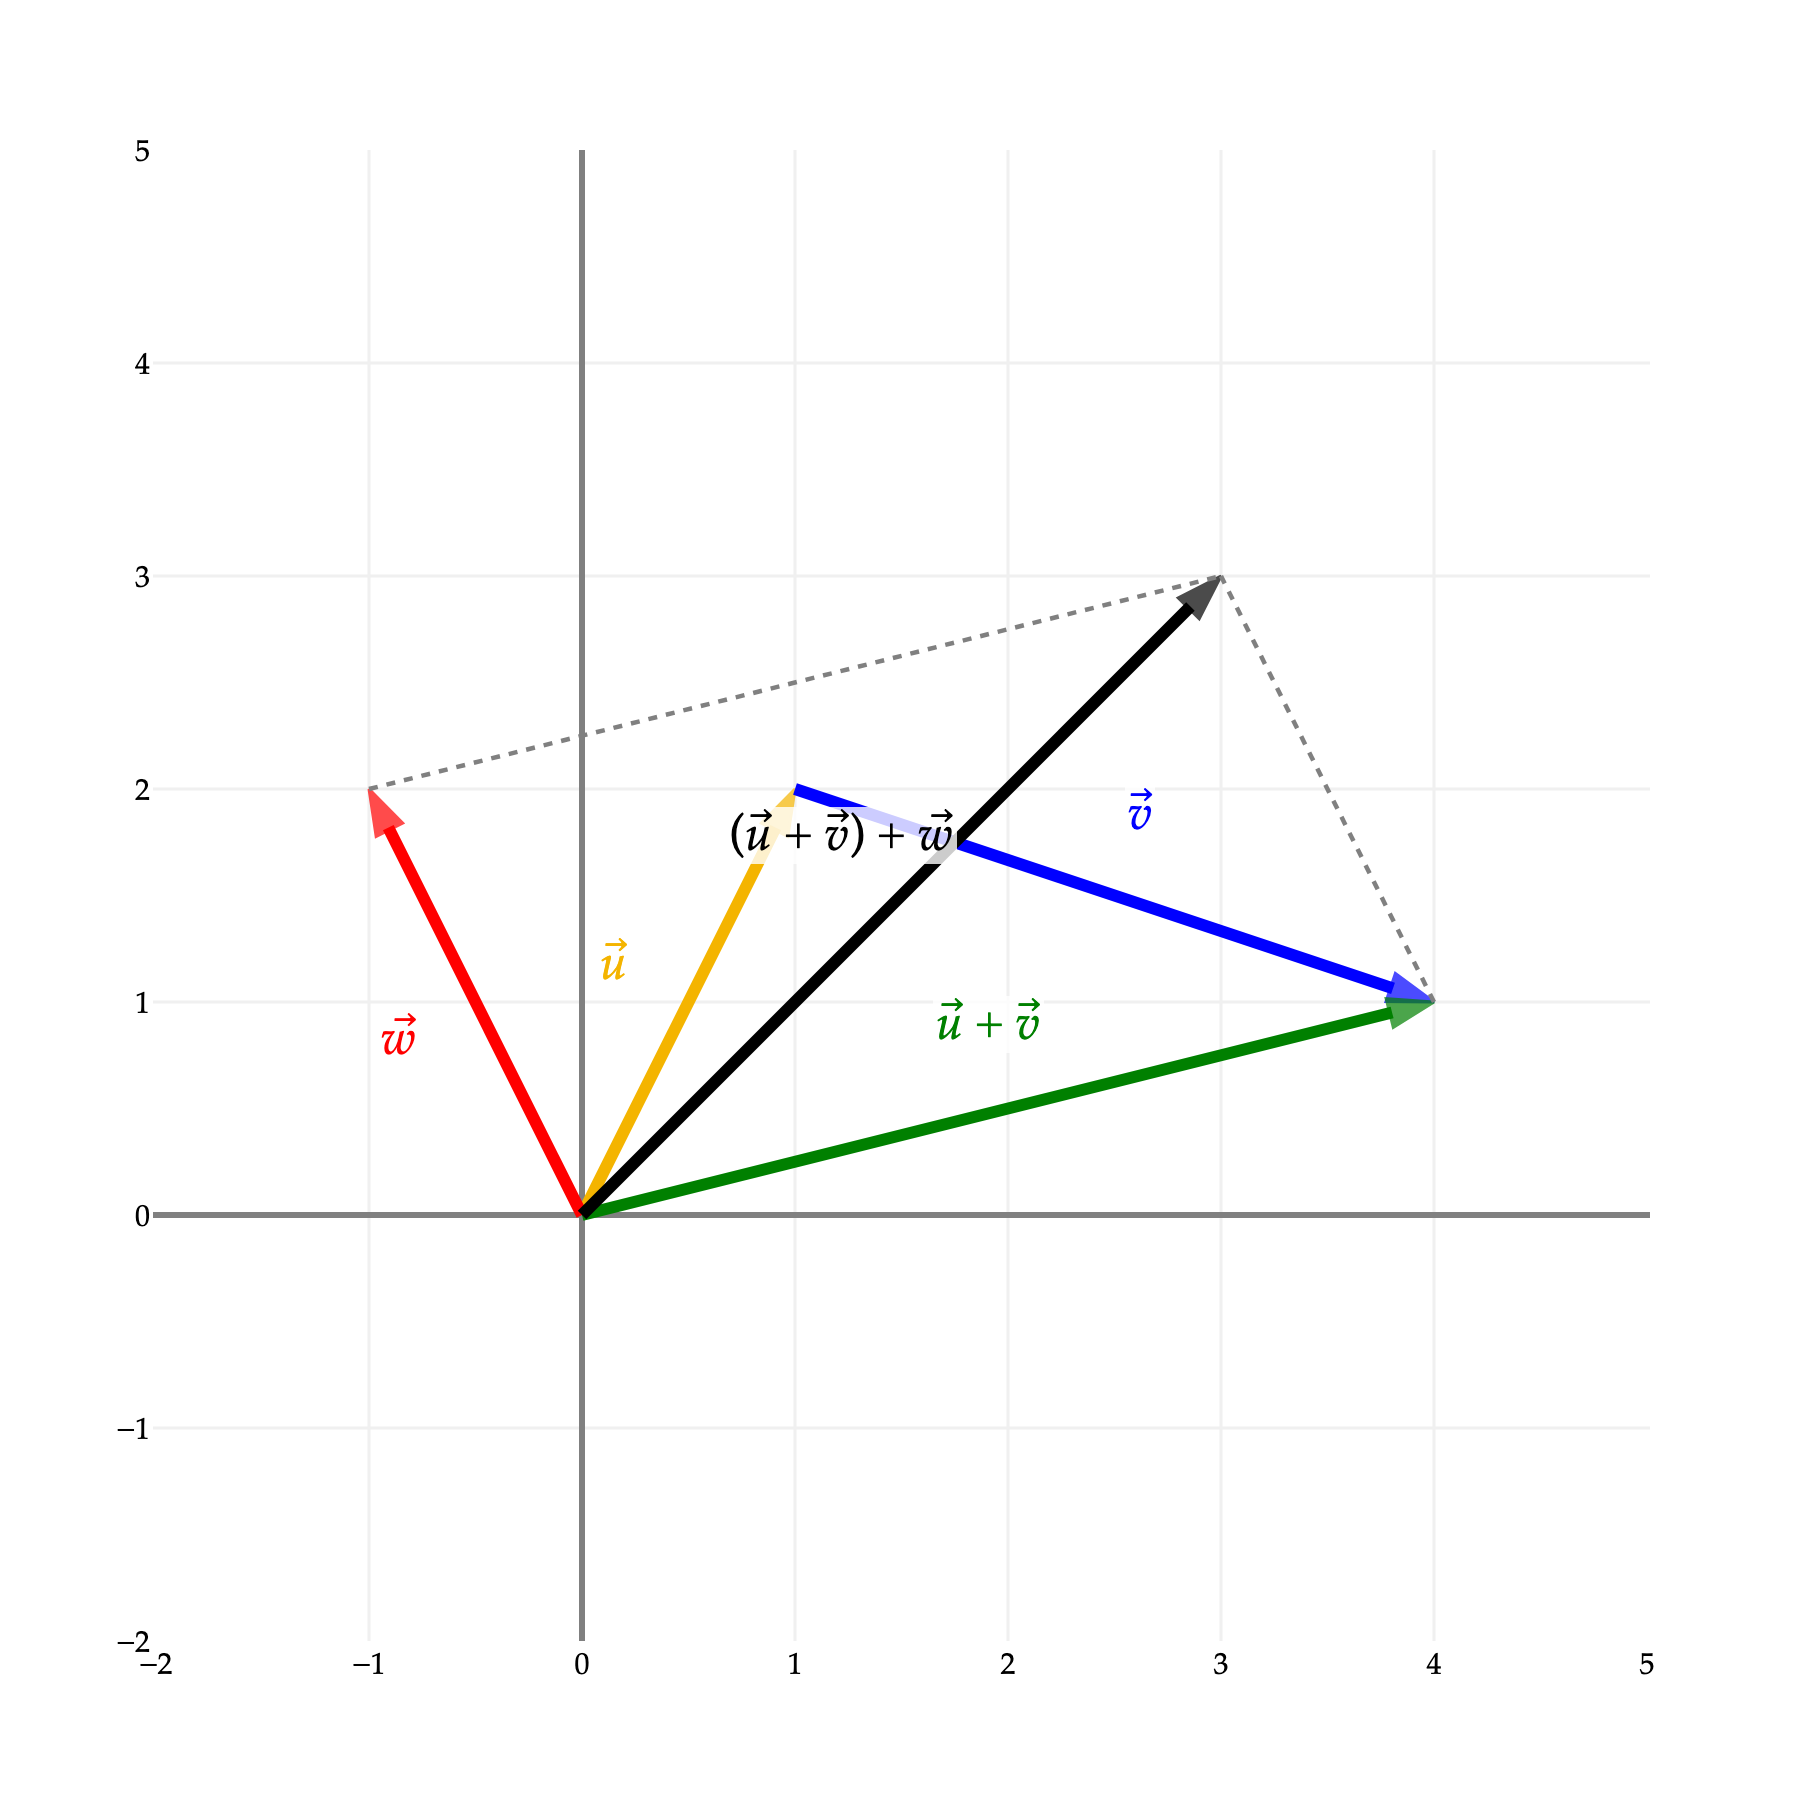

In [14]:
# 2. Geometric addition showing (u+v) first, then adding w
vectors_2 = [
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),
    (((1, 2), (4, 1)), 'blue', '<i>v</i>\u20D7'),                       # v at tip of u
    (((0, 0), (4, 1)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7'),       # Sum u+v
    (((0, 0), (-1, 2)), 'red', '<i>w</i>\u20D7'),                         # w at tip of u+v
    (((0, 0), (3, 3)), 'black', '(<i>u</i>\u20D7 + <i>v</i>\u20D7) + <i>w</i>\u20D7') # Total sum
]

fig2 = plot_vectors_non_origin(vectors_2, vdeltax=0.4, vdeltay=0.4)

# Add dashed guide line from origin to w just for reference if they need to see w's original trajectory
fig2.add_trace(go.Scatter(
    x=[4, 3], y=[1, 3], mode='lines', 
    line=dict(color = 'grey', width=1.5, dash='dot'), showlegend=False, hoverinfo='skip'
))
fig2.add_trace(go.Scatter(
    x=[-1, 3], y=[2, 3], mode='lines', 
    line=dict(color = 'grey',width=1.5, dash='dot'), showlegend=False, hoverinfo='skip'
))

fig2.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig2.update_xaxes(range=[-2, 5], tickvals=np.arange(-2, 6))
fig2.update_yaxes(range=[-2, 5], tickvals=np.arange(-2, 6))

fig2.show(scale=3)

This time, let us add the vectors $\vec v$ and $\vec w$ first, and then add $\vec u$. From this we obtain the same result:
$$ \vec u + (\vec v + \vec w) = \begin{bmatrix}-1\\2\end{bmatrix}  + \begin{bmatrix}-1\\2\end{bmatrix}  = \begin{bmatrix}-1\\2\end{bmatrix}.$$

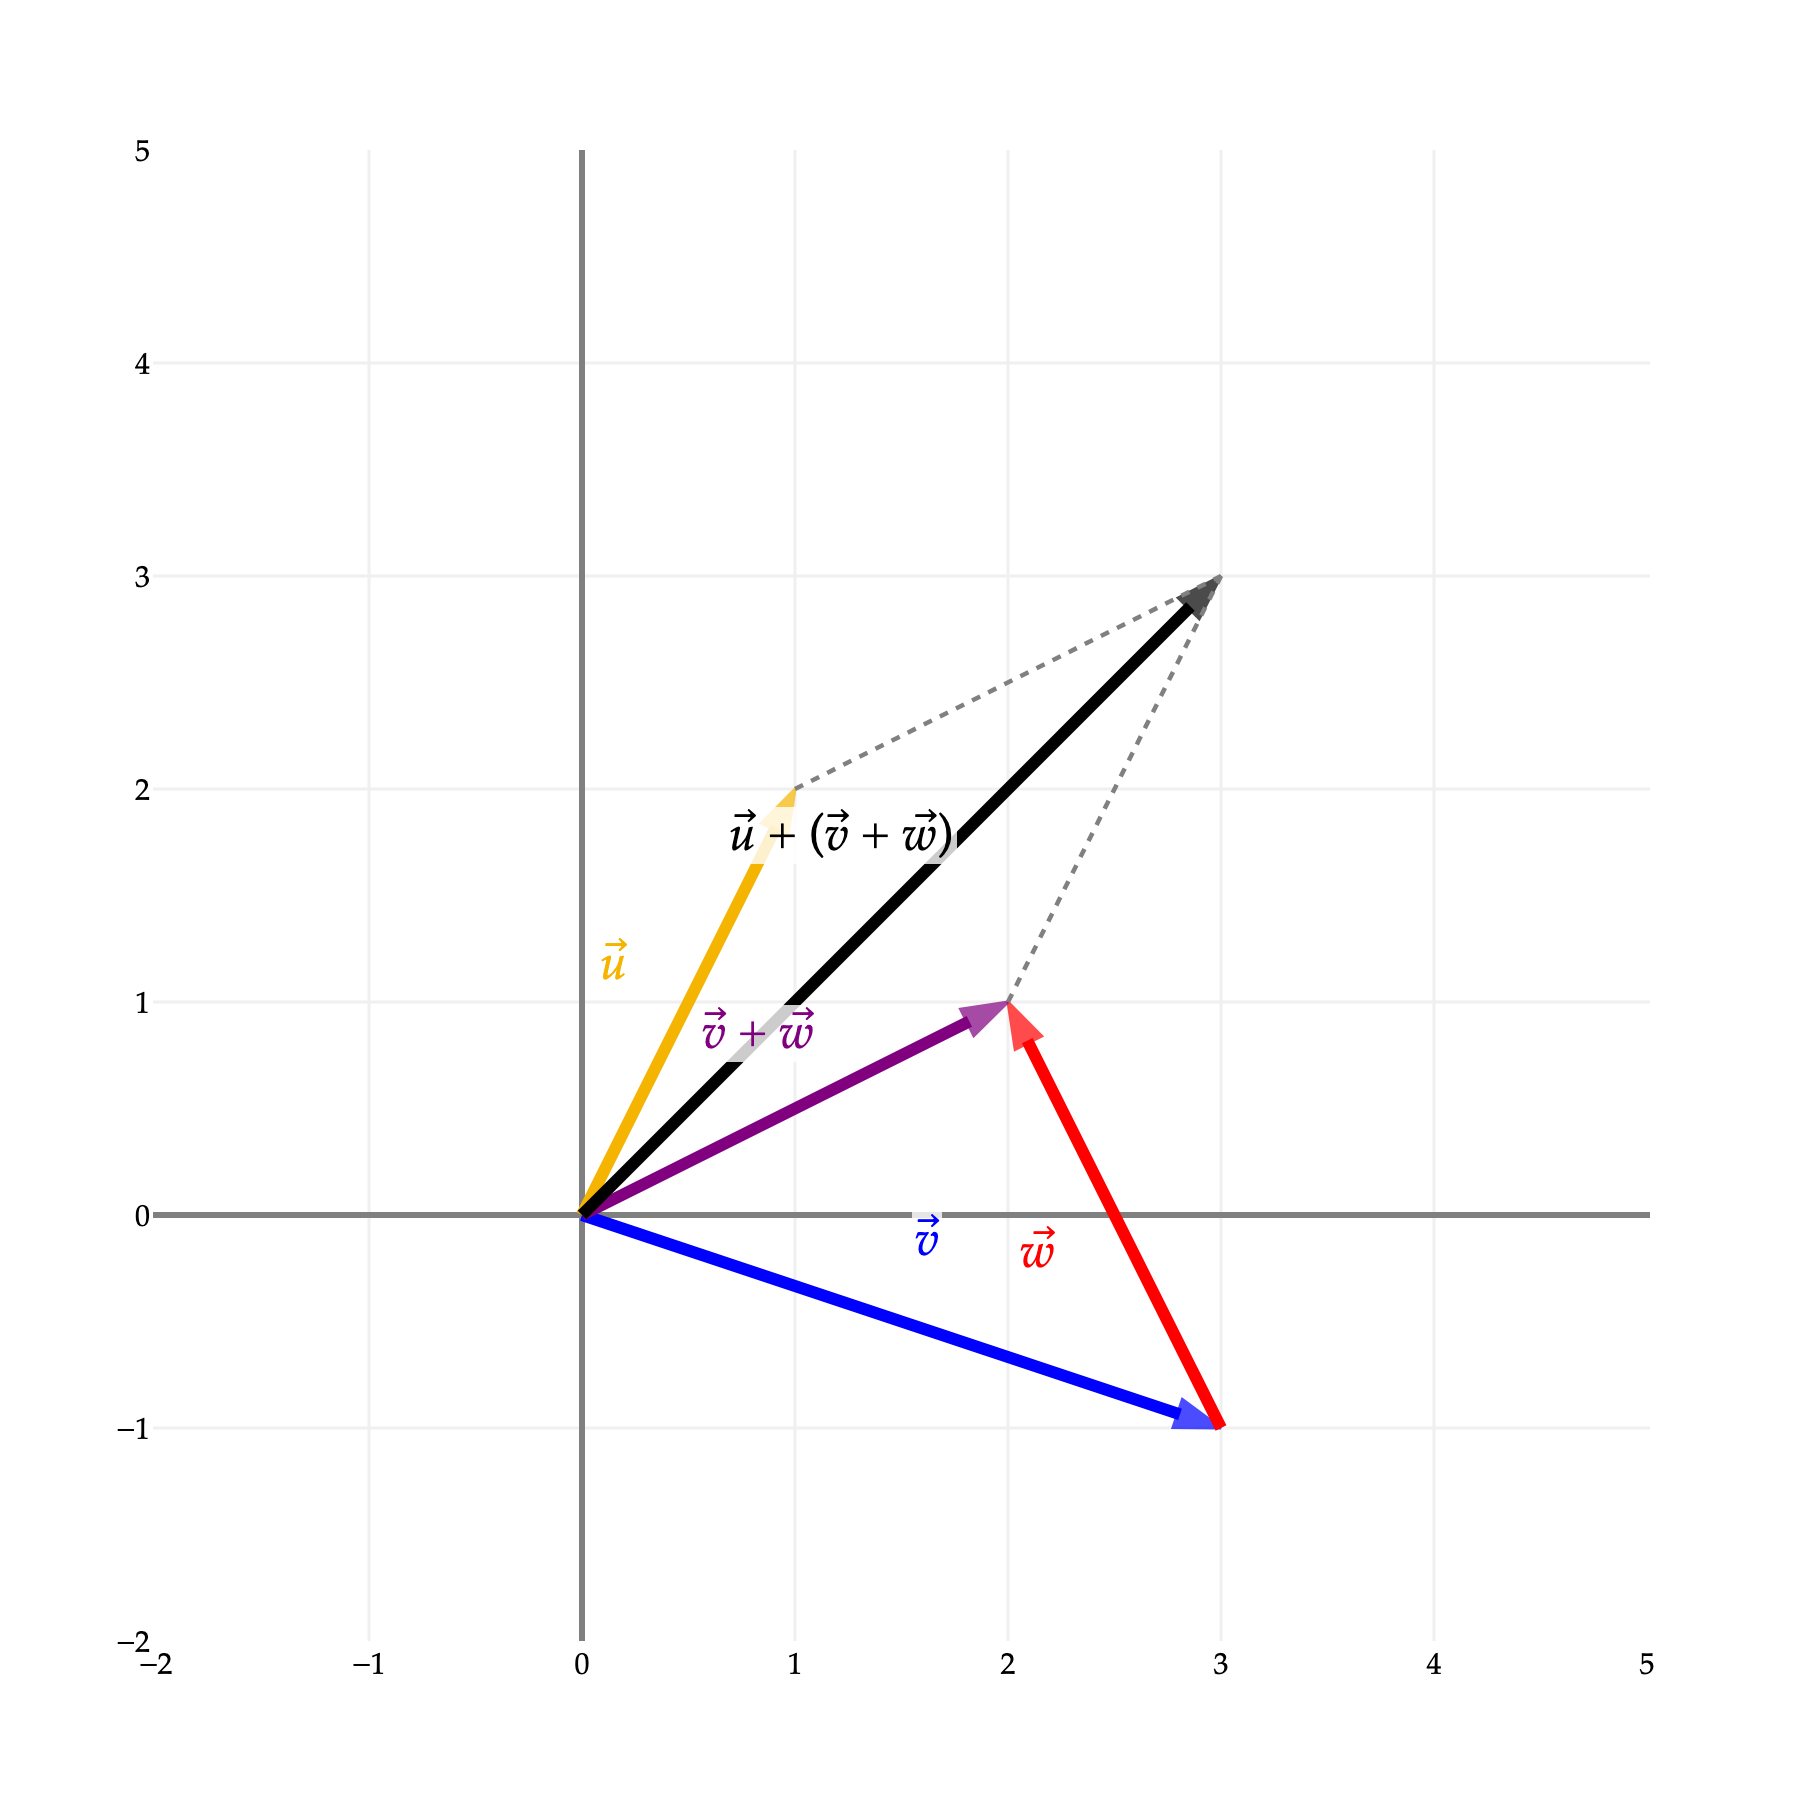

In [16]:
# 3. Geometric addition showing (v+w) first, then adding it to u
vectors_3 = [
    (((0, 0), (3, -1)), 'blue', '<i>v</i>\u20D7'),                       # v at origin
    (((3, -1), (2, 1)), 'red', '<i>w</i>\u20D7'),                         # w at tip of v
    (((0, 0), (2, 1)), 'purple', '<i>v</i>\u20D7 + <i>w</i>\u20D7'),      # Sum v+w
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),                     # u at origin
    (((0, 0), (3, 3)), 'black', '<i>u</i>\u20D7 + (<i>v</i>\u20D7 + <i>w</i>\u20D7)') # Total sum
]

fig3 = plot_vectors_non_origin(vectors_3, vdeltax=0.4, vdeltay=0.4)

fig3.add_trace(go.Scatter(
    x=[2, 3], y=[1, 3], mode='lines', 
    line=dict(color = 'grey', width=1.5, dash='dot'), showlegend=False, hoverinfo='skip'
))
fig3.add_trace(go.Scatter(
    x=[1, 3], y=[2, 3], mode='lines', 
    line=dict(color = 'grey',width=1.5, dash='dot'), showlegend=False, hoverinfo='skip'
))

fig3.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig3.update_xaxes(range=[-2, 5], tickvals=np.arange(-2, 6))
fig3.update_yaxes(range=[-2, 5], tickvals=np.arange(-2, 6))

fig3.show(scale=3)

## Scalar multiplication

### Algebraic definition

**Scalar multiplication** is multiplying a number -- or a _scalar_, recall -- to a vector of any size. This is done by multiplying the number on every entry. Here is an example where we multiply the scalars 3 and $-1$ to the vector $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$:
$$ 3 \begin{bmatrix} 1 \\ 2 \end{bmatrix} = \begin{bmatrix} 3 \\ 6 \end{bmatrix},\quad
-1 \begin{bmatrix} 1 \\ 2 \end{bmatrix} = \begin{bmatrix} -1 \\ -2 \end{bmatrix}. $$

More generally, scalar multiplication is defined as follows:
$$ c \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n\end{bmatrix}
= \begin{bmatrix} cx_1 \\ cx_2 \\ \vdots \\ cx_n\end{bmatrix}.$$

### Geometric interpretation

Similar to vector addition, scalar multiplication can also be viewed geometrically. Multiplying a scalar acts on a vector by keeping its direction by stretching its size by the scalar. Let's visualize this again using the first example we have above.

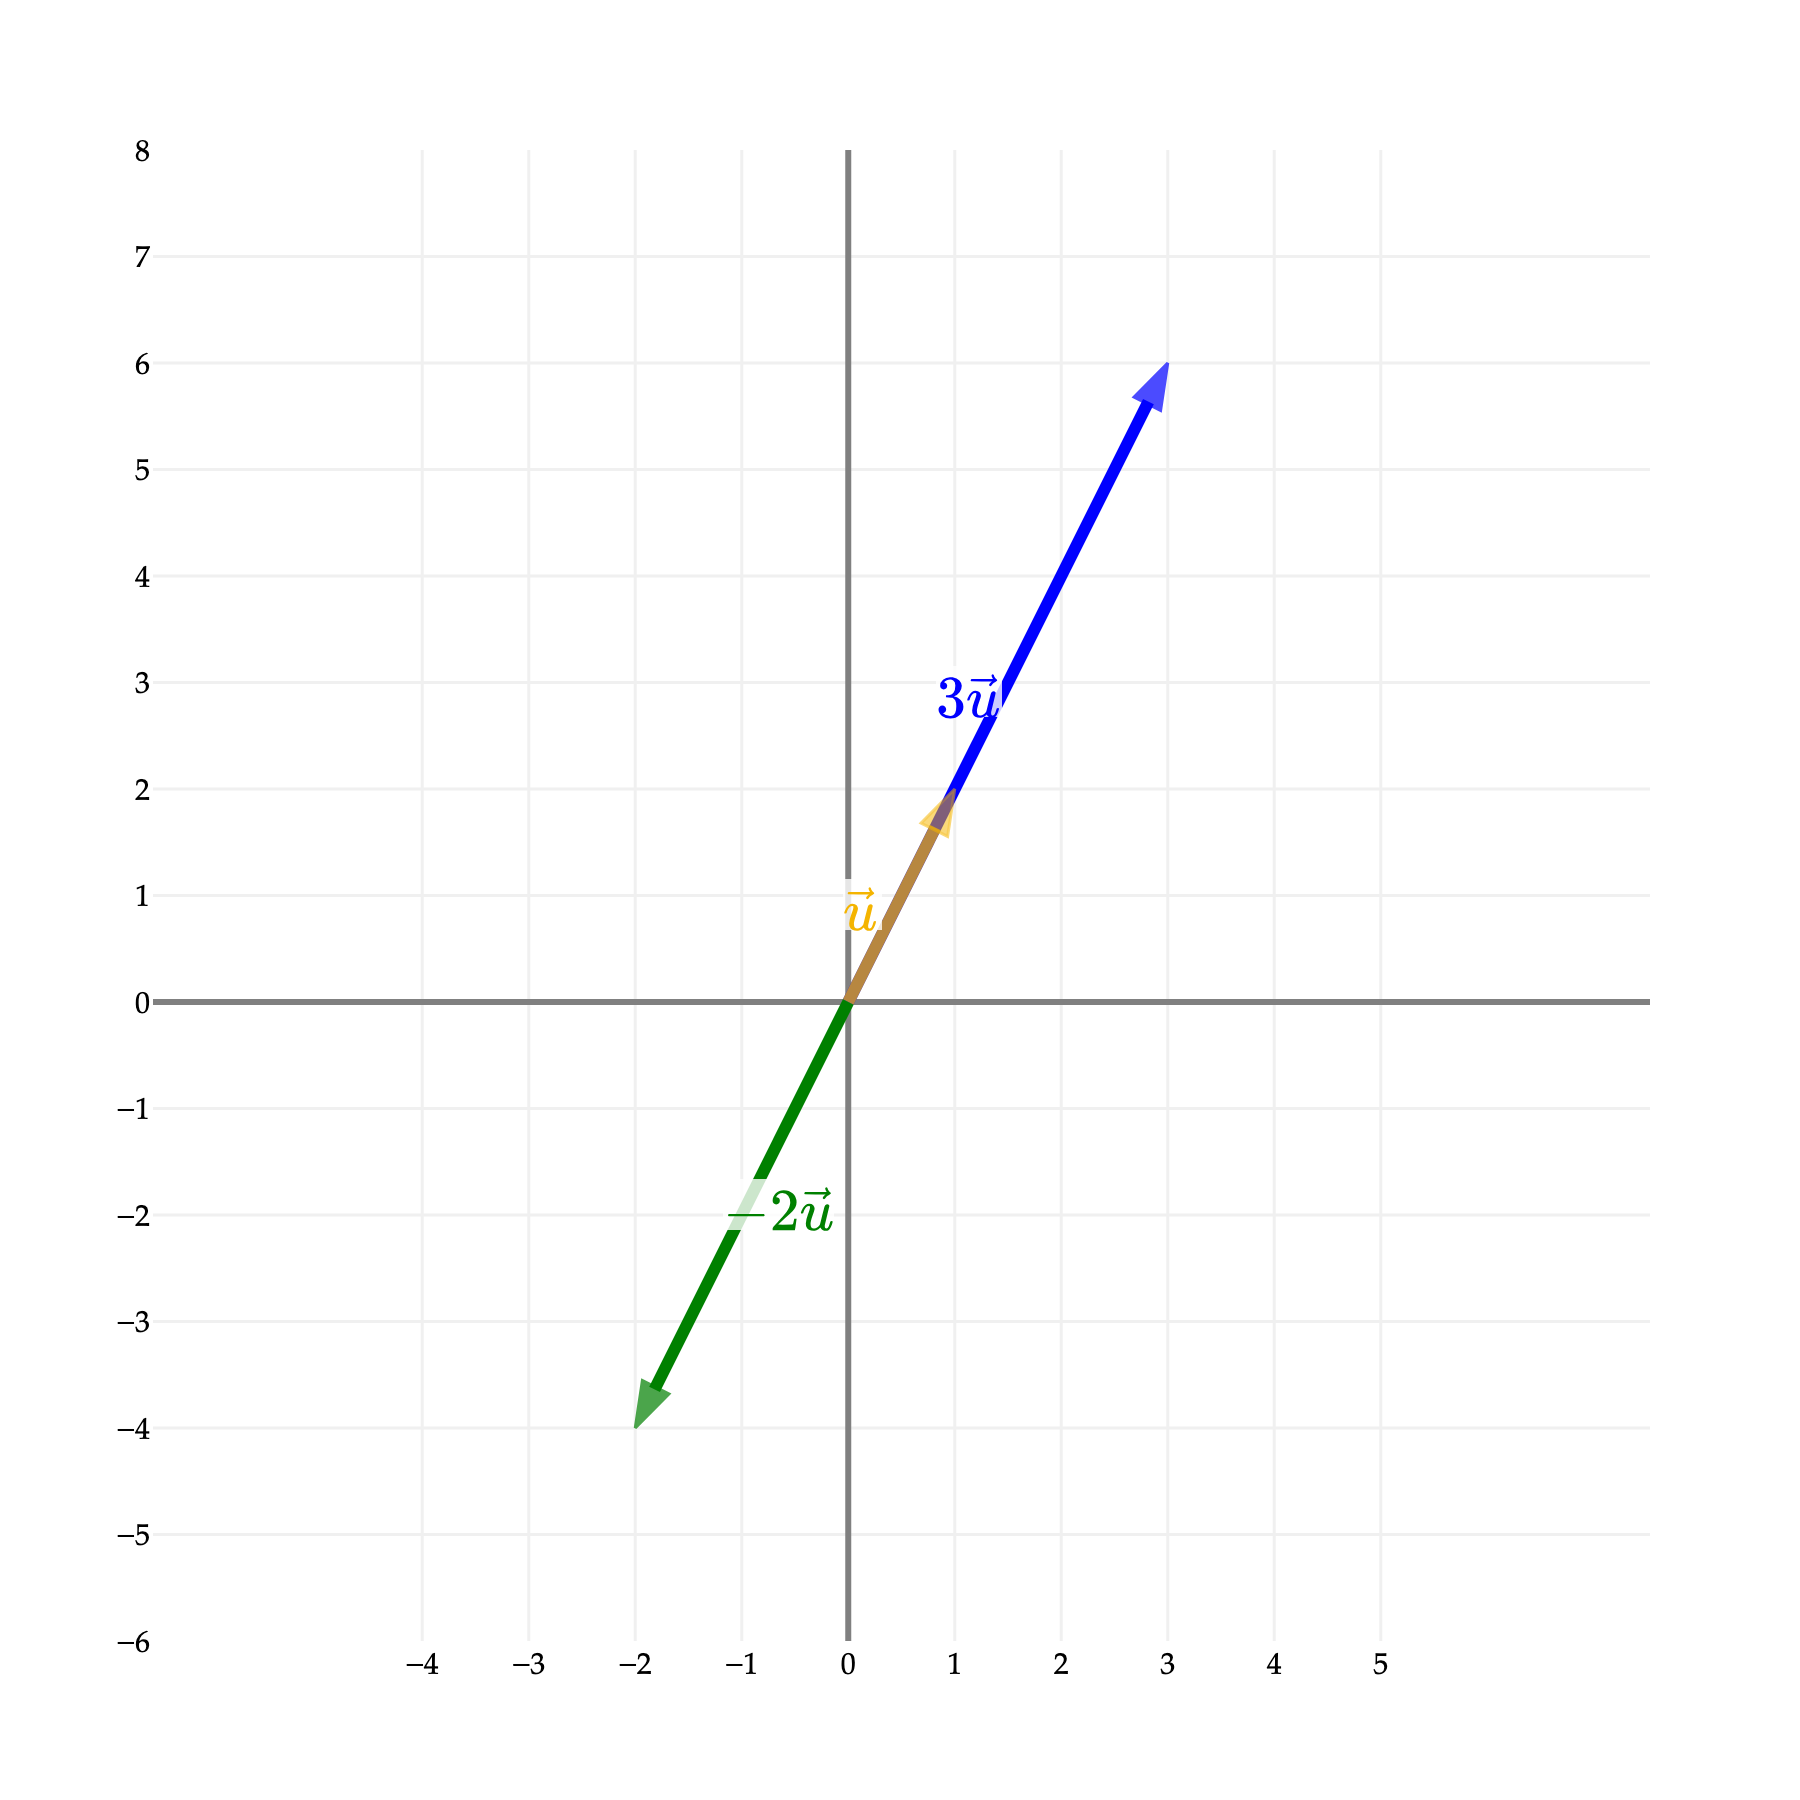

In [4]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors

# Draw the longer positive vector first, then the shorter one, then the negative one
vectors = [
    ((3, 6), 'blue', r'$3\vec{u}$'),
    ((1, 2), 'rgba(244, 180, 0, 0.75)', r'$\vec{u}$'), 
    ((-2, -4), 'green', r'$-2\vec{u}$')
]

# Adjust vdeltax and vdeltay to position the labels
fig = plot_vectors(vectors, vdeltax=0.4, vdeltay=-0.2)

# Lock the aspect ratio so the scaling is visually accurate
# Slightly increased width and height to accommodate the larger spatial range
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Expanded the grid ranges to frame the new negative coordinates comfortably
fig.update_xaxes(range=[-4, 5], tickvals=np.arange(-4, 6))
fig.update_yaxes(range=[-6, 8], tickvals=np.arange(-6, 9))

fig.show(scale=3)

Note that we have to be slightly careful about saying that the direction is preserved, since the vector $-2\vec u$ has doubled in size but is pointing exactly opposite of $\vec u$. This is what happens in general when we multiply a negative scalar to a vector.

### Subtraction of vectors

Now that we have talked about vector addition and scalar multiplication, we can combine the two concepts to define what is means to _subtract_ two vectors. Algebraically, it is simply defined by
$$ \vec u - \vec v = \vec u + (-\vec v).$$
Vector addition and subtraction can be summarized by one picture involving a parallelogram, as it was hinted above. The following picture can be obtained by recalling that $-\vec v$ is simply the vector $\vec v$ pointing in the opposite direction, and using our interpretation of vector addition as connecting two vectors.

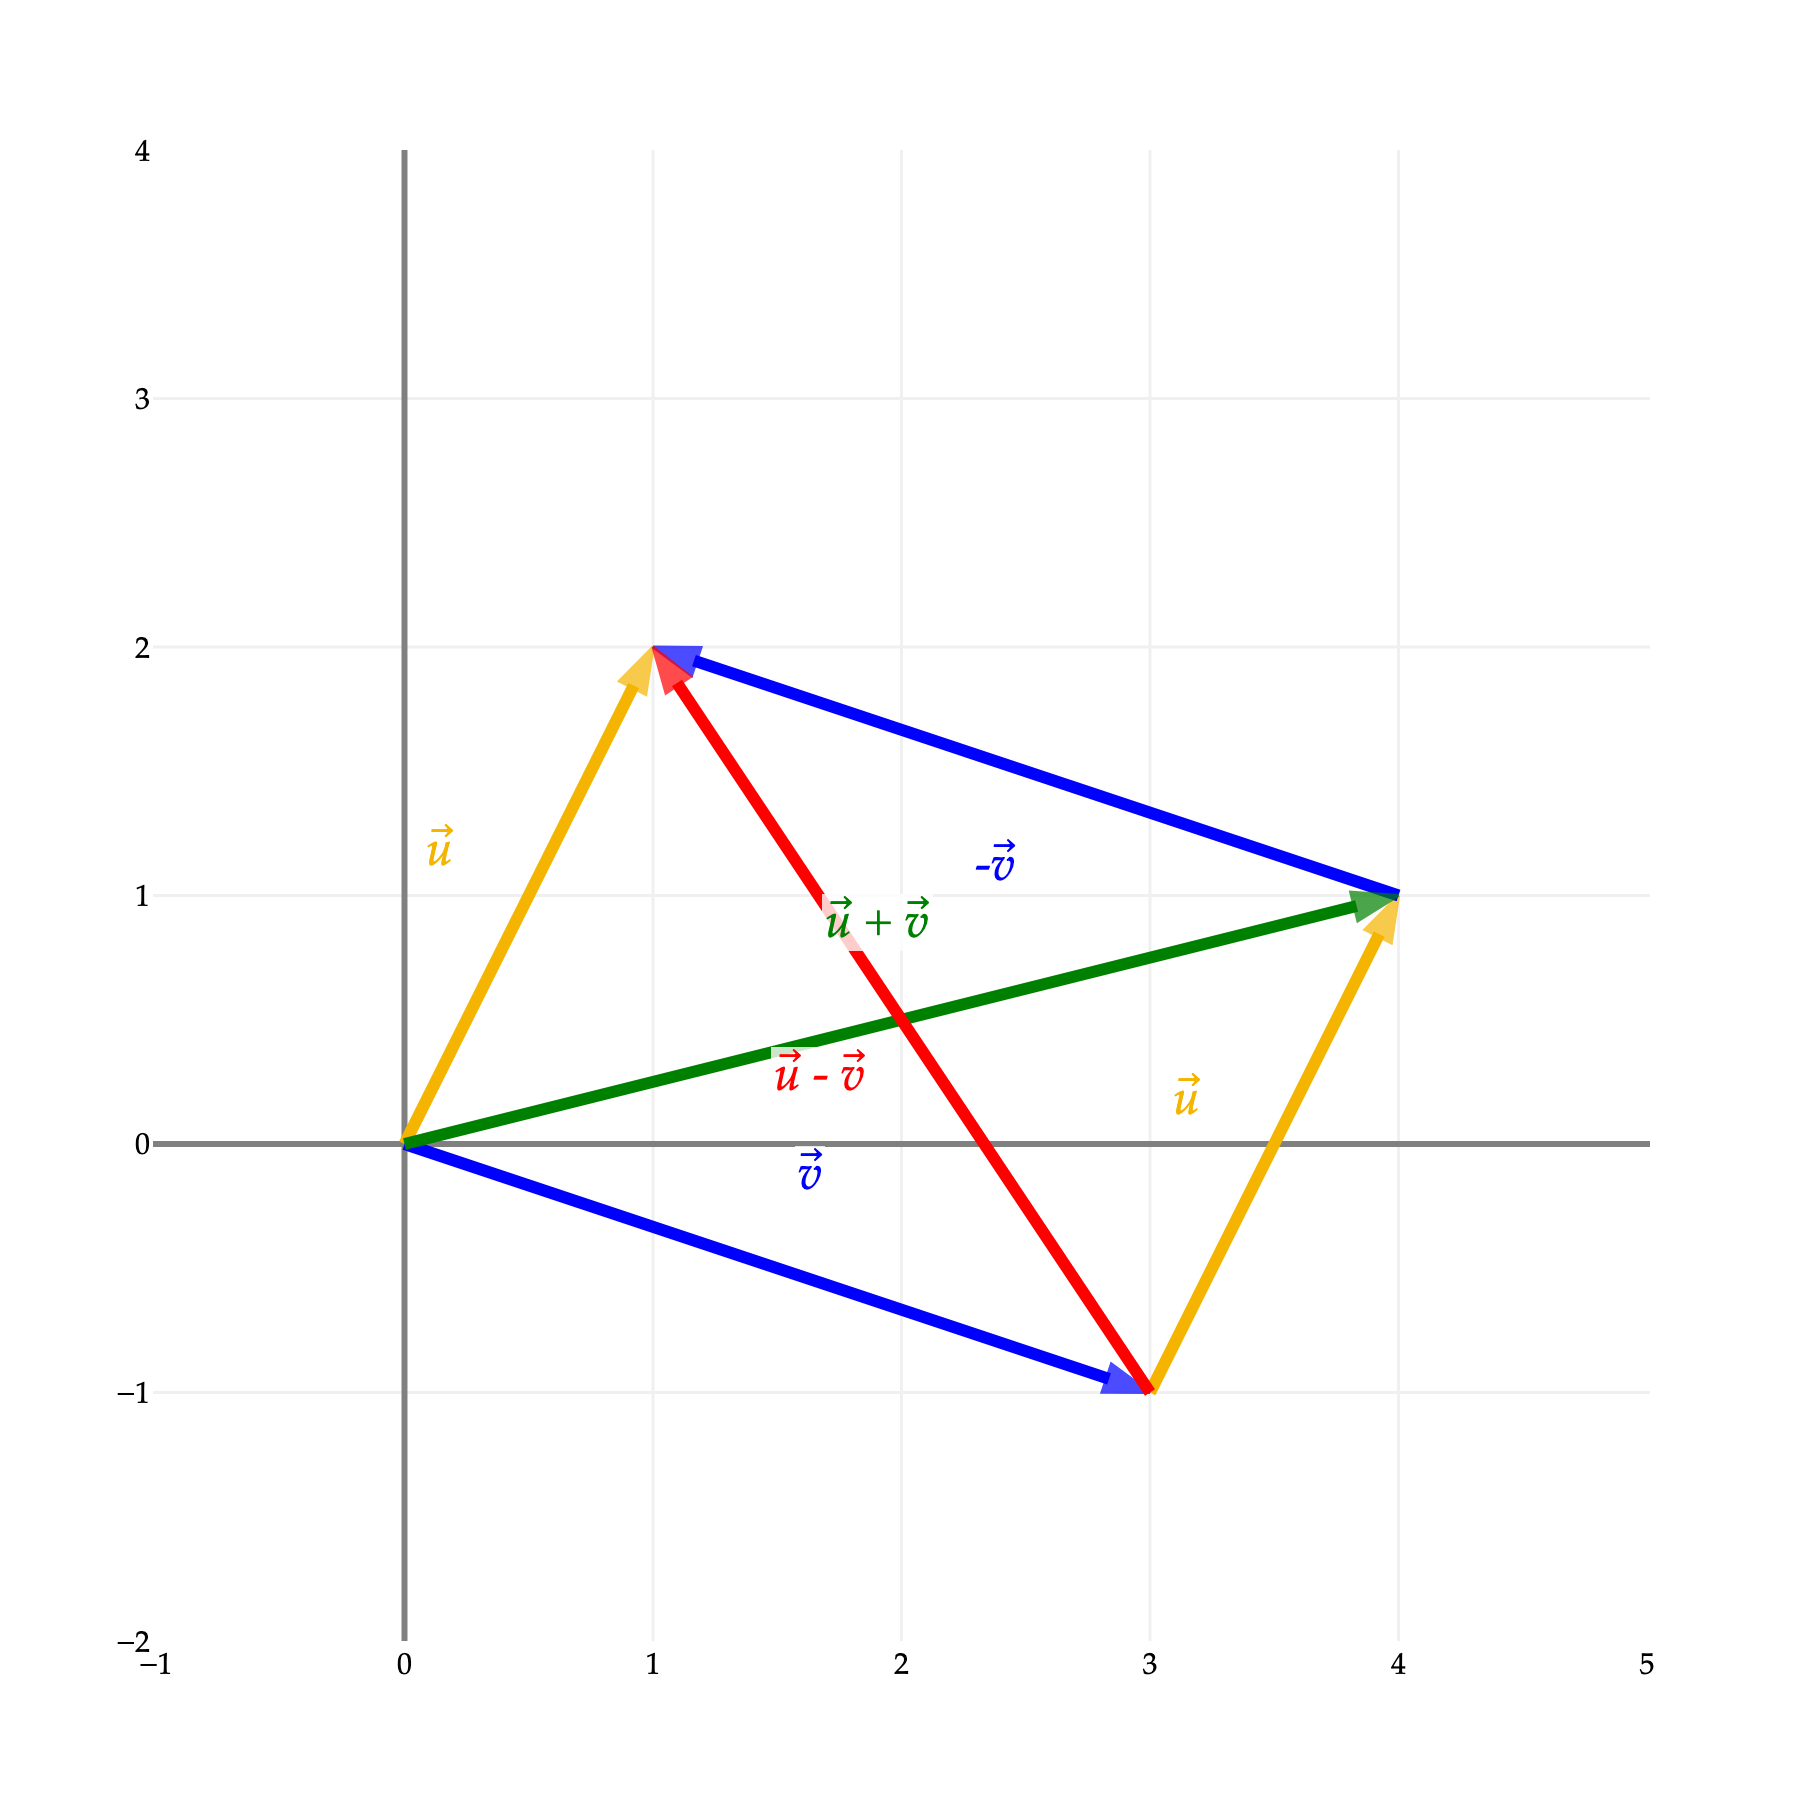

In [19]:
vectors = [
    (((0, 0), (1, 2)), '#f4b400', '<i>u</i>\u20D7'),
    (((3, -1), (4, 1)), '#f4b400', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), 'blue', '<i>v</i>\u20D7'),
    (((4, 1), (1 , 2)), 'blue', '<i>-v</i>\u20D7'),
    (((0, 0), (4, 1)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7'),
    (((3, -1), (1, 2)), 'red', '<i>u</i>\u20D7 - <i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)


# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid to comfortably frame the entire parallelogram
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

# Export statically
fig.show(scale=3)

In short, we can find the vector $\vec u - \vec v$ be connecting the endpoint of $\vec v$ to the endpoint of $\vec u$.